### Load Data

In [2]:
import pandas as pd

df = pd.read_csv('laptops.csv')
df

,name,price,rating,description
0,Asus VivoBook X441NA-GA190,$295.99,3,"Asus VivoBook X441NA-GA190 Chocolate Black, 14..."
1,Prestigio SmartBook 133S Dark Grey,$299,2,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ..."
2,Prestigio SmartBook 133S Gold,$299,4,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ..."
3,Aspire E1-510,$306.99,3,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux"
4,Lenovo V110-15IAP,$321.94,3,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1..."
...,...,...,...,...
112,Lenovo Legion Y720,$1399,3,"Lenovo Legion Y720, 15.6"" FHD IPS, Core i7-770..."
113,Asus ROG Strix GL702VM-GC146T,$1399,3,"Asus ROG Strix GL702VM-GC146T, 17.3"" FHD, Core..."
114,Asus ROG Strix GL702ZC-GC154T,$1769,4,"Asus ROG Strix GL702ZC-GC154T, 17.3"" FHD, Ryze..."
115,Asus ROG Strix GL702ZC-GC209T,$1769,1,"Asus ROG Strix GL702ZC-GC209T, 17.3"" FHD IPS, ..."


### Analisis Produk

Tujuan analisis ini adalah membantu pengguna memahami isi katalog laptop dengan cepat:

- Merek apa yang paling banyak tersedia?
- Kategori laptop apa yang paling dominan?
- Merek mana yang memiliki rating rata-rata terbaik?
- Berapa harga termurah, termahal, dan rata-rata produk?
- Produk apa saja yang paling menarik berdasarkan rating dan harga?

Data merek dan kategori dibuat dari informasi yang tersedia pada nama serta deskripsi produk.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Menyiapkan kolom angka agar dapat dihitung dan dibandingkan.
df['price_num'] = (
    df['price']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')
df['search_text'] = (df['name'].fillna('') + ' ' + df['description'].fillna('')).str.lower()

# Merek diturunkan dari nama produk karena CSV belum memiliki kolom merek khusus.
brand_patterns = {
    'Acer': r'\b(?:acer|aspire)\b',
    'Asus': r'\b(?:asus|vivobook|zenbook)\b',
    'Dell': r'\b(?:dell|inspiron|latitude|xps)\b',
    'Lenovo': r'\b(?:lenovo|thinkpad|ideapad)\b',
    'Prestigio': r'\bprestigio\b',
    'Toshiba': r'\b(?:toshiba|portege|satellite)\b',
    'HP': r'\b(?:hp|hewlett)\b',
    'Apple': r'\b(?:apple|macbook)\b',
}

def detect_brand(text):
    for brand, pattern in brand_patterns.items():
        if pd.Series(text).str.contains(pattern, regex=True).iloc[0]:
            return brand
    return 'Lainnya'


df['brand'] = df['search_text'].apply(detect_brand)

# Kategori sederhana untuk membantu pembacaan hasil oleh pengguna non-teknis.
def detect_category(text):
    if any(word in text for word in ['gaming', 'game', 'nitro', 'predator']):
        return 'Gaming'
    if any(word in text for word in ['chromebook', 'chrome os']):
        return 'Chromebook'
    if any(word in text for word in ['ultrabook', 'thin', 'slim', 'notebook']):
        return 'Tipis & Ringan'
    return 'Laptop Umum'


df['category'] = df['search_text'].apply(detect_category)

print(f'Data siap dianalisis: {len(df)} produk')

Data siap dianalisis: 117 produk


In [8]:
summary = pd.DataFrame({
    'Indikator': [
        'Total produk',
        'Jumlah merek',
        'Harga termurah',
        'Harga termahal',
        'Harga rata-rata',
        'Rating rata-rata',
    ],
    'Hasil': [
        f"{len(df):,} produk",
        f"{df['brand'].nunique()} merek",
        f"${df['price_num'].min():,.2f}",
        f"${df['price_num'].max():,.2f}",
        f"${df['price_num'].mean():,.2f}",
        f"{df['rating_num'].mean():.2f} dari 5",
    ],
})

display(summary.style.hide(axis='index').set_caption('Ringkasan Katalog Laptop'))

Indikator,Hasil
Total produk,117 produk
Jumlah merek,9 merek
Harga termurah,$295.99
Harga termahal,"$1,799.00"
Harga rata-rata,$909.39
Rating rata-rata,2.34 dari 5


In [9]:
brand_summary = (
    df.groupby('brand', as_index=False)
    .agg(Jumlah_Produk=('name', 'count'), Rating_Rata_Rata=('rating_num', 'mean'), Harga_Rata_Rata=('price_num', 'mean'))
    .sort_values(['Jumlah_Produk', 'Rating_Rata_Rata'], ascending=[False, False])
)
brand_summary['Rating_Rata_Rata'] = brand_summary['Rating_Rata_Rata'].round(2)
brand_summary['Harga_Rata_Rata'] = brand_summary['Harga_Rata_Rata'].round(2)
display(brand_summary.style.hide(axis='index').set_caption('Perbandingan Merek'))

brand,Jumlah_Produk,Rating_Rata_Rata,Harga_Rata_Rata
Acer,27,2.480000,622.590000
Lenovo,24,2.500000,945.150000
Dell,21,2.430000,1090.330000
Asus,21,2.240000,970.580000
Lainnya,9,2.110000,987.890000
HP,5,1.800000,812.680000
Toshiba,5,1.600000,1226.610000
Apple,3,2.330000,1313.640000
Prestigio,2,3.000000,299.000000


In [10]:
category_summary = (
    df.groupby('category', as_index=False)
    .agg(Jumlah_Produk=('name', 'count'), Rating_Rata_Rata=('rating_num', 'mean'), Harga_Termurah=('price_num', 'min'))
    .sort_values('Jumlah_Produk', ascending=False)
)
category_summary['Rating_Rata_Rata'] = category_summary['Rating_Rata_Rata'].round(2)
category_summary['Harga_Termurah'] = category_summary['Harga_Termurah'].round(2)
display(category_summary.style.hide(axis='index').set_caption('Perbandingan Kategori'))

category,Jumlah_Produk,Rating_Rata_Rata,Harga_Termurah
Laptop Umum,102,2.360000,295.990000
Tipis & Ringan,10,2.300000,404.230000
Gaming,5,2.000000,809.000000


In [11]:
best_value = df.sort_values(['rating_num', 'price_num'], ascending=[False, True]).head(10)
display(
    best_value[['name', 'brand', 'category', 'price', 'rating']]
    .reset_index(drop=True)
    .style.hide(axis='index')
    .set_caption('10 Produk dengan Rating Tertinggi')
)

name,brand,category,price,rating
Prestigio SmartBook 133S Gold,Prestigio,Laptop Umum,$299,4
Acer Aspire ES1-572 Black,Acer,Laptop Umum,$379.95,4
Acer Aspire 3 A315-31 Black,Acer,Laptop Umum,$391.48,4
Asus VivoBook E502NA-GO022T Dark Blue,Asus,Laptop Umum,$399.99,4
Acer Aspire 3 A315-31 Black,Acer,Laptop Umum,$408.98,4
Acer Aspire ES1-732 Black,Acer,Laptop Umum,$410.46,4
Asus VivoBook 15 X540NA-GQ026T,Asus,Laptop Umum,$410.66,4
Acer Extensa 15 (2540) Black,Acer,Laptop Umum,$439.73,4
Dell Vostro 15,Dell,Laptop Umum,$488.78,4
Acer Aspire 3 A315-51 Black,Acer,Laptop Umum,$494.71,4


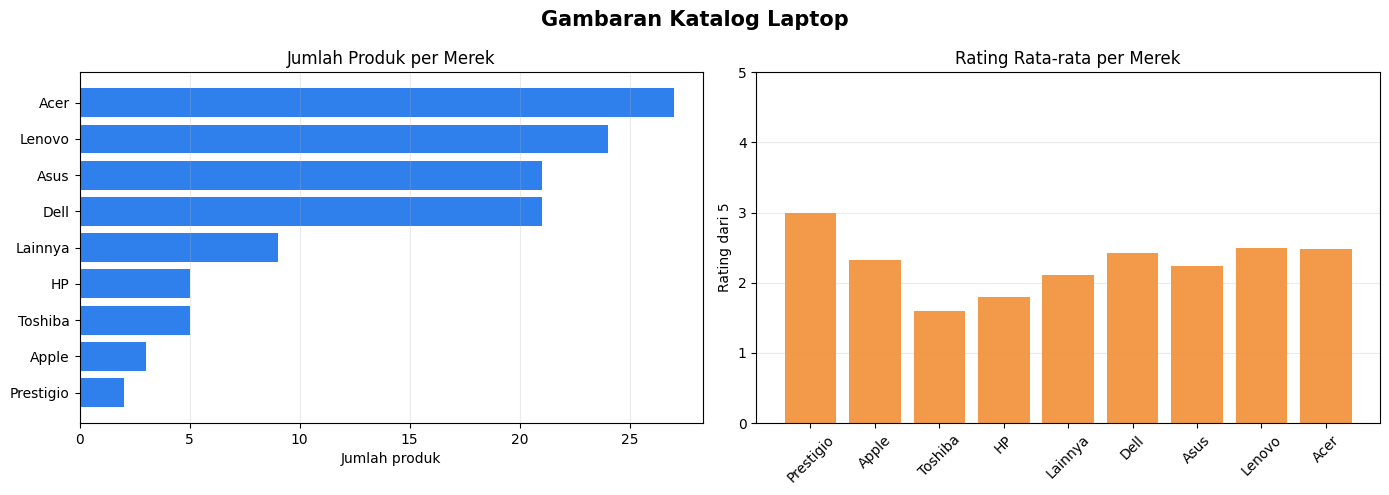

In [12]:
# Grafik utama untuk memperlihatkan jumlah produk dan rating rata-rata tiap merek.
chart_data = brand_summary.sort_values('Jumlah_Produk', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(chart_data['brand'], chart_data['Jumlah_Produk'], color='#2f80ed')
axes[0].set_title('Jumlah Produk per Merek')
axes[0].set_xlabel('Jumlah produk')
axes[0].grid(axis='x', alpha=0.25)

axes[1].bar(chart_data['brand'], chart_data['Rating_Rata_Rata'], color='#f2994a')
axes[1].set_title('Rating Rata-rata per Merek')
axes[1].set_ylabel('Rating dari 5')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.25)

plt.suptitle('Gambaran Katalog Laptop', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()